In [234]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [235]:
df = pd.read_csv('AirPassNew.csv')

In [236]:
df.shape

(10366, 25)

In [237]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


# Пропуски

In [238]:
print(df.isnull().sum())

Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             26
satisfaction                          0


In [239]:
print(f'Процент строк с пропусками в данных: {round(df.isnull().sum().sum()/len(df),4):.2%}')

Процент строк с пропусками в данных: 0.25%


In [240]:
df = df.dropna()

In [241]:
# Проверка, что пропуски удалены
print('Количество пропусков:', df.isnull().sum().sum())
print('Количество строк после удаления пропусков', df.shape[0])

Количество пропусков: 0
Количество строк после удаления пропусков 10340


## Вывод по пропускам 
Пропуски были только в столбце Arrival Delay in Minutes (26 пропусков). Строки с пропусками были удалены, так как составляли менее 0,3% данных.

# Дубликаты

In [242]:
print('Найдено дублей:', df.duplicated().sum())

Найдено дублей: 0


# Выбросы

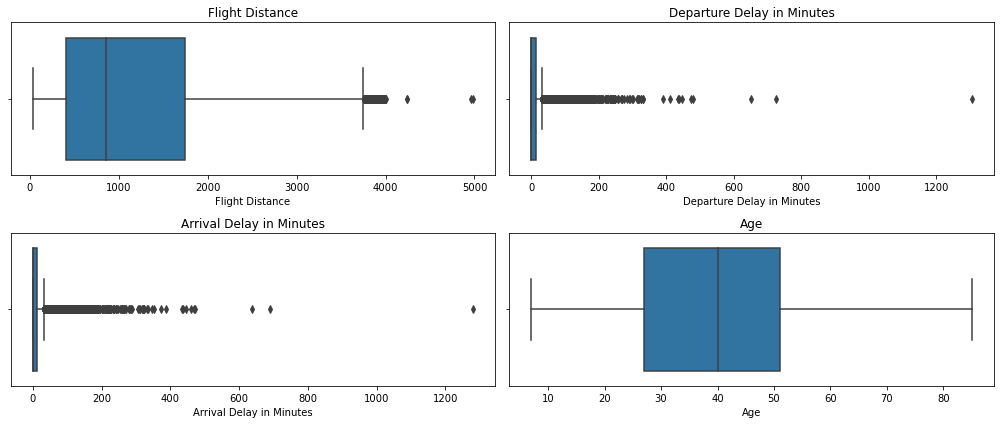

In [243]:
# Проверим выбросы для столбцов с числовыми данными
fig, ax = plt.subplots(2, 2, figsize=(14, 6))
cols = ['Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Age']
axes_flat = ax.flatten()

for i in range(4):
    sns.boxplot(data=df, x=cols[i], ax=axes_flat[i])
    axes_flat[i].set_title(cols[i])

plt.tight_layout()
plt.show()

## Анализ выбросов 
Анализ проведен для числовых признаков: Flight Distance, Departure Delay, Arrival Delay, Age. Оценки сервиса (1–5) не имеют выбросов. Много выбросов в столбцах: Flight Distance, Departure Delay in Minutes и Arrival Delay in Minutes.

# Очистка

In [244]:
# Функция для удаления выбросов по IQR
def outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [245]:
print('Количество выбросов по IQR в столбце: ')
for col in cols[:-1]:
    print(f'{col}: {len(df) - len(outliers_iqr(df, col))}')

Количество выбросов по IQR в столбце: 
Flight Distance: 208
Departure Delay in Minutes: 1349
Arrival Delay in Minutes: 1398


In [246]:
# Удалим выбросы в столбце Flight Distance
df_clean = outliers_iqr(df, 'Flight Distance').copy()

In [247]:
print(f'В столбце Flight Distance было удалено {len(df) - len(df_clean)} выбросов')
print('Количество строк после удаления выбросов в столбце Flight Distance', len(df_clean))

В столбце Flight Distance было удалено 208 выбросов
Количество строк после удаления выбросов в столбце Flight Distance 10132


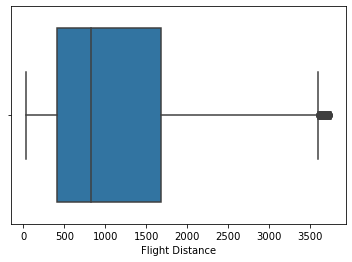

In [248]:
# Проверим, что выбросы удалены
sns.boxplot(data = df_clean, x = 'Flight Distance');

## Вывод по очистке
Для столбца Flight Distance удалены выбросы по IQR (208 строк). Выбросы в задержках не удалялись, так как это редкие, но реальные события, важные для анализа удовлетворенности при сбоях.

# Оценка общей удовлетворенности

In [249]:
# Проверим распределение удовлетворенных и неудовлетворенных пассажиров
pd.concat([df_clean['satisfaction'].value_counts(), 
           df_clean['satisfaction'].value_counts(normalize = True).round(2).mul(100)], 
          axis = 1, 
          keys = ['количество','процент'])

,количество,процент
satisfaction,,
neutral or dissatisfied,5817,57.0
satisfied,4315,43.0


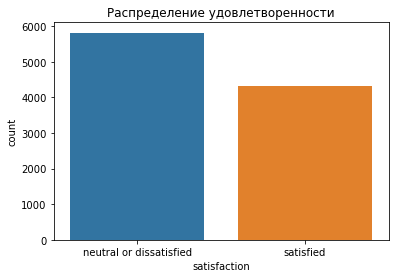

In [250]:
sns.countplot(x = 'satisfaction', data = df_clean)
plt.title('Распределение удовлетворенности');

In [251]:
# Создадим столбец, в котором значению neutral or dissatisfied будет соответствовать 0, а значению satisfied 1
df_clean['satisfaction_0_1'] = df_clean['satisfaction'].apply(lambda x: 1 if x == 'satisfied' else 0)

# Гипотеза 1
**Длинные перелеты снижают удовлетворенность.**

In [252]:
# Создадим столбец с категориями длительности полета
q1 = df_clean['Flight Distance'].quantile(0.25)
q2 = df_clean['Flight Distance'].quantile(0.5)
q3 = df_clean['Flight Distance'].quantile(0.75)

def distance_category (dist):
    if dist < q1:
        return '1. Короткий перелет'
    elif dist < q2:
        return '2. Средний перелет'
    elif dist < q3:
        return '3. Длинный перелет'
    else:
        return '4. Очень длинный перелет'

df_clean['Flight distance category'] = df_clean['Flight Distance'].apply(distance_category)

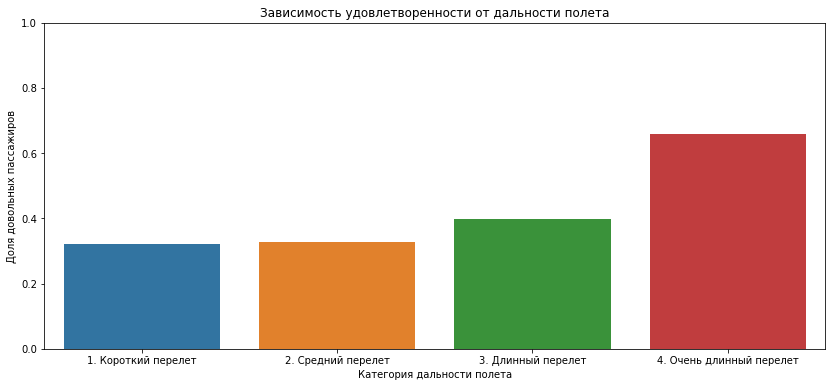

In [253]:
flight_distance_satisfaction = df_clean.groupby('Flight distance category')['satisfaction_0_1'].mean().reset_index()

plt.figure(figsize=(14,6))
sns.barplot(data = flight_distance_satisfaction, x = 'Flight distance category', y = 'satisfaction_0_1')
plt.title('Зависимость удовлетворенности от дальности полета')
plt.xlabel('Категория дальности полета')
plt.ylabel('Доля довольных пассажиров')
plt.ylim(0, 1)
plt.show()

In [254]:
flight_distance_satisfaction.round(2)

,Flight distance category,satisfaction_0_1
0,1. Короткий перелет,0.32
1,2. Средний перелет,0.33
2,3. Длинный перелет,0.40
3,4. Очень длинный перелет,0.66


## Вывод по гипотезе 1 (не подтвердилась)  
При длительных перелетах удовлетворенность растет. Рассмотрим подробнее группу ***4. Очень длинный перелет*** и оценим ее состав.

In [255]:
long_distance = df_clean[df_clean['Flight distance category'] == '4. Очень длинный перелет']
print('Количество пассажиров в группе 4. Очень длинный перелет:', len(long_distance))

Количество пассажиров в группе 4. Очень длинный перелет: 2533


In [256]:
# Посмотрим распределение по разным признакам
print("Распределение по классам:")
print(long_distance['Class'].value_counts(normalize=True).round(2))

print("Распределение по лояльности пассажира:")
print(long_distance['Customer Type'].value_counts(normalize=True).round(2))

Распределение по классам:
Class
Business    0.85
Eco         0.13
Eco Plus    0.02
Name: proportion, dtype: float64
Распределение по лояльности пассажира:
Customer Type
Loyal Customer       0.97
disloyal Customer    0.03
Name: proportion, dtype: float64


## Итог по гипотезе 1
После рассмотрения группы с самыми длинными перелетами было выявлено, что в ней 97% лояльных пассажиров и 85% пассажиров бизнес-класса. Поскольку в группе высокая доля лояльных пассажиров и пассажиров бизнес-класса, можно предположить, что именно эти факторы, а не длина перелета, определяют высокую удовлетворенность. Далее проверим гипотезы о влиянии класса и лояльности на удовлетворенность.

# Гипотеза 2
**Лояльность влияет на удовлетворенность.**

In [257]:
print(df_clean.groupby('Customer Type')['satisfaction_0_1'].mean().round(2))

Customer Type
Loyal Customer       0.47
disloyal Customer    0.23
Name: satisfaction_0_1, dtype: float64


## Вывод по гипотезе 2 (подтвердилась)  
В среднем лояльные пассажиры более удовлетворены (на 47%).

# Гипотеза 3
**Класс обслуживания влияет на удовлетворенность.**

In [258]:
print(df_clean.groupby('Class')['satisfaction_0_1'].mean().round(2))

Class
Business    0.68
Eco         0.19
Eco Plus    0.24
Name: satisfaction_0_1, dtype: float64


## Вывод по гипотезе 3 (подтвердилась)
Пассажиры бизнес-класса значительно чаще удовлетворены сервисом (68%), чем пассажиры эконома (19%) и эконом-плюс (24%).

# Сервисные факторы
**Проверим, какие факторы оказывают наибольшее влияние на удовлетворенность пассажиров.**

In [259]:
services = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 
           'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 
           'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

means_services = df_clean.groupby('satisfaction_0_1')[services].mean().transpose().round(2)
means_services.columns = ['dissatisfied', 'satisfied']
means_services['difference'] = means_services['satisfied'] - means_services['dissatisfied']
means_services_sorted = means_services.sort_values('difference', ascending=False)
print(means_services_sorted)

                                   dissatisfied  satisfied  difference
Online boarding                            2.65       4.01        1.36
Inflight entertainment                     2.86       3.96        1.10
Seat comfort                               3.01       3.94        0.93
Leg room service                           2.98       3.83        0.85
On-board service                           3.01       3.84        0.83
Cleanliness                                2.91       3.73        0.82
Inflight wifi service                      2.41       3.17        0.76
Food and drink                             2.94       3.56        0.62
Baggage handling                           3.36       3.96        0.60
Inflight service                           3.38       3.96        0.58
Checkin service                            3.05       3.60        0.55
Ease of Online booking                     2.56       3.02        0.46
Gate location                              2.97       2.96       -0.01
Depart

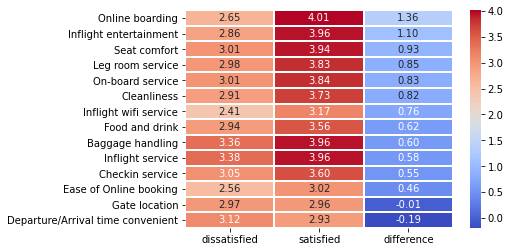

In [260]:
sns.heatmap(means_services_sorted, linecolor = 'white', linewidths = 1, annot=True, cmap='coolwarm', fmt='.2f');

## Вывод по сервисным факторам
Наибольшее влияние на общую удовлетворенность оказывают онлайн-регистрация, развлечения на борту и комфорт сидений. Расположение выхода и время вылета/прилета практически не влияют на удовлетворенность.

# Задержки
**Проверим, как задержки влияют на общую удовлетворенность.**

In [261]:
# Создадим столбец с категориями задержки
def delay_category(minutes):
    if minutes <= 0:
        return '1. Без задержки'
    elif minutes <= 15:
        return '2. До 15 мин'
    elif minutes <= 30:
        return '3. 15-30 мин'
    elif minutes <= 60:
        return '4. 30-60 мин'
    elif minutes <= 120:
        return '5. 1-2 часа'
    else:
        return '6. Более 2 часов'

df_clean['Departure delay category'] = df_clean['Departure Delay in Minutes'].apply(delay_category)

In [262]:
df_clean['Departure delay category'].value_counts()

Departure delay category
1. Без задержки     5693
2. До 15 мин        2173
3. 15-30 мин         873
4. 30-60 мин         700
5. 1-2 часа          437
6. Более 2 часов     256
Name: count, dtype: int64

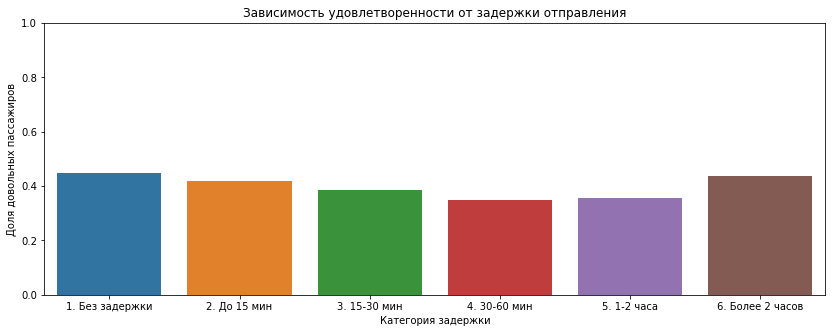

In [263]:
departure_delay_satisfaction = df_clean.groupby('Departure delay category')['satisfaction_0_1'].mean().reset_index()

plt.figure(figsize=(14,5))
sns.barplot(data = departure_delay_satisfaction, x = 'Departure delay category', y = 'satisfaction_0_1')
plt.title('Зависимость удовлетворенности от задержки отправления')
plt.xlabel('Категория задержки')
plt.ylabel('Доля довольных пассажиров')
plt.ylim(0, 1)
plt.show()

In [264]:
print(departure_delay_satisfaction.round(3))

  Departure delay category  satisfaction_0_1
0          1. Без задержки             0.449
1             2. До 15 мин             0.419
2             3. 15-30 мин             0.384
3             4. 30-60 мин             0.349
4              5. 1-2 часа             0.357
5         6. Более 2 часов             0.438


## Вывод по влиянию задержек  
С ростом задержки удовлетворенность постепенно снижается:
- Без задержки - 45,6% довольных
- Задержка до 15 минут - 42,5%
- Задержка 15-30 минут - 39,1%
- Задержка 30-60 минут - 35,5%

**Замечание:**  
При задержках 1-2 часа удовлетворенность практически не отличается от группы 30-60 минут, а при задержке более 2 часов неожиданно повышается до 43,8% - почти до уровня "без задержки".

Это требует дополнительного анализа.

# Долгие задержки
**Подробнее рассмотрим группу с самой долгой задержкой (более 2 часов).**

In [265]:
long_delay = df_clean[df_clean['Departure delay category'] == '6. Более 2 часов']
print('Количество пассажиров в группе с задержкой более 2 часов:', len(long_delay))

Количество пассажиров в группе с задержкой более 2 часов: 256


In [266]:
print("Распределение по классам:")
print(long_delay['Class'].value_counts(normalize=True).round(2))

print("Распределение по лояльности пассажира:")
print(long_delay['Customer Type'].value_counts(normalize=True).round(2))

print("Распределение по цели поездки:")
print(long_delay['Type of Travel'].value_counts(normalize=True).round(2))

Распределение по классам:
Class
Business    0.51
Eco         0.44
Eco Plus    0.05
Name: proportion, dtype: float64
Распределение по лояльности пассажира:
Customer Type
Loyal Customer       0.81
disloyal Customer    0.19
Name: proportion, dtype: float64
Распределение по цели поездки:
Type of Travel
Business travel    0.75
Personal Travel    0.25
Name: proportion, dtype: float64


In [267]:
print("Удовлетворенность в группе с задержкой более 2 часов")
print("Общая удовлетворенность в группе:", round(long_delay['satisfaction_0_1'].mean(),2))

print("По классу:")
print(long_delay.groupby('Class')['satisfaction_0_1'].mean().round(2))

print("По лояльности пассажира:")
print(long_delay.groupby('Customer Type')['satisfaction_0_1'].mean().round(2))

print("По цели поездки:")
print(long_delay.groupby('Type of Travel')['satisfaction_0_1'].mean().round(2))

Удовлетворенность в группе с задержкой более 2 часов
Общая удовлетворенность в группе: 0.44
По классу:
Class
Business    0.68
Eco         0.16
Eco Plus    0.38
Name: satisfaction_0_1, dtype: float64
По лояльности пассажира:
Customer Type
Loyal Customer       0.48
disloyal Customer    0.27
Name: satisfaction_0_1, dtype: float64
По цели поездки:
Type of Travel
Business travel    0.55
Personal Travel    0.10
Name: satisfaction_0_1, dtype: float64


## Предварительный вывод
В этой группе 256 человек. Из них:
- 51% - бизнес-класс
- 81% - лояльные пассажиры
- 75% - деловые поездки

Общая удовлетворенность в группе с задержкой более 2 часов - 44%. При этом удовлетворенность:
- в бизнес-классе 68%
- у лояльных пассажиров 48%
- во время деловых поездок 55%

In [268]:
# Построим сводную таблицу для оценки средней удовлетворенности по классу и лояльности в группе с сильной задержкой
pd.pivot_table(long_delay, 
               values='satisfaction_0_1', 
               index='Class', 
               columns='Customer Type', 
               aggfunc='mean').round(2)

Customer Type,Loyal Customer,disloyal Customer
Class,,
Business,0.72,0.38
Eco,0.15,0.20
Eco Plus,0.36,0.50


In [269]:
# Построим сводную таблицу для подсчета количества пассажиров по классу и лояльности в группе с сильной задержкой
pd.pivot_table(long_delay, 
               values='satisfaction_0_1', 
               index='Class', 
               columns='Customer Type', 
               aggfunc='count', 
                margins=True)

Customer Type,Loyal Customer,disloyal Customer,All
Class,,,
Business,115,16,131
Eco,82,30,112
Eco Plus,11,2,13
All,208,48,256


## Вывод по влиянию долгих задержек
При задержке более 2 часов программа лояльности повышает удовлетворенность только в бизнес-классе (+34%).
В экономе и эконом-плюс нелояльные пассажиры удовлетворены несколько больше, чем лояльные (разница -5% и -14% соответственно). Однако эти различия могут быть обусловлены малым количеством данных в некоторых подгруппах.

# Итоги анализа

1. **Общая удовлетворенность** - 43% довольных, 57% недовольных.  


2. **Задержки** снижают удовлетворенность. Исключение - группа с задержкой более 2 часов (удовлетворенность 44%), что объясняется высокой долей бизнес-класса (51%) и лояльных клиентов (81%).  


3. **Класс обслуживания** сильно связан с удовлетворенностью: удовлетворенных в бизнес-классе - 68%, в эконом - 19%.  


4. **Лояльные пассажиры** удовлетворены чаще (47% против 23% у нелояльных). Однако при задержке более 2 часов лояльность дает прирост только в бизнес-классе (+34%).  


5. **Сервисные факторы** с наибольшим влиянием на удовлетворенность: онлайн-регистрация, развлечения на борту и комфорт сидений.  


6. **Длина перелета** не снижает удовлетворенность. Рост в группе "Очень длинный перелет" обусловлен высокой долей бизнес-класса (85%) и лояльных пассажиров (97%).  

**Ключевые факторы: класс обслуживания, лояльность, онлайн-регистрация, развлечения на борту, комфорт сидений.**